In [2]:
import sys
sys.path.append("../../src/")
from common_imports import *
from scipy.integrate import solve_ivp
from numpy import conj
from numpy import linalg as la
import kibble_zurek as kz
from time import time
from joblib import Parallel, delayed
import numpy as np
import time_evolved_z_correlators as zz
#Load Pauli Matrices
s3,s1,s2 = array([[1,0],[0,-1]],dtype=complex),array([[0, 1],[1,0]],dtype=complex), array([[0,-1j],[1j,0]],dtype=complex)


In [3]:
def g(t,tau,alpha=1):
    """
    Time Dependent g(t) with a potential nonlinearity in quench speed controlled by alpha.
    """
    return 1 - np.sign(t)*abs(t/tau)**(alpha)
#TFIM functions
def a(q,g):
    return g+ cos(q)
def b(q,g):
    return sin(q)
def w(q,g):
    return sqrt(g*g+2*g*cos(q)+1)
def BdG(q,g):
    return -2*(a(q,g)*s3+b(q,g)*s2)
#Time Evolution

In [4]:

def BdG_Evolution(t,U,tau,q,alpha=1):
    return -1j*BdG(q,g(t,tau,alpha))@U
def BdG_stationary_evolve(t,U,q,g):
    return -1j*BdG(q,g)@U       

In [68]:

def BdG_Evolution(t,U,tau,q,alpha=1):
    return -1j*BdG(q,g(t,tau,alpha))@U
def BdG_stationary_evolve(t,U,q,g):
    return -1j*BdG(q,g)@U       
def evolve_mode(q, t0, tau, t_eval,alpha=1):
    V0 = la.eigh(BdG(q, g(t0, tau,alpha)))[1][:, 1]
    sol = solve_ivp(
        BdG_Evolution,
        [t0, tau],
        V0,
        args=(tau, q,alpha),
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.05
    )
    V1 = array([sol.y[0][-1],sol.y[1][-1]],dtype=complex)
    t_eval2= np.linspace(t_eval[-1],t_eval[-1]+5,len(t_eval))
    #print(g(t_eval[-1],tau,alpha))
    sol2= solve_ivp(
        BdG_stationary_evolve,
        [t_eval2[0],t_eval2[-1]],
        V1,
        args =(q,g(t_eval[-1],tau,alpha)),
        t_eval=t_eval2,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
        max_step=0.05
    )

    u = np.concatenate( (sol.y[0] , sol2.y[0]) )
    v = np.concatenate( (sol.y[1] , sol2.y[1]) )
    return u,v


def landau_states(tau, L,alpha=1,ts=0):
    N_timesteps = 300
    if ts==0:
        t0 = -tau
        tf = tau/2
    else:
        t0,tf = ts 
    n = np.arange(0, L // 2)
    k = (2 * n + 1) * pi / L
    t_eval = np.linspace(t0, tf, N_timesteps)
    t_plot = np.concatenate( (t_eval, np.linspace(t_eval[-1],t_eval[-1]+5,len(t_eval))))
    results = Parallel(n_jobs=-1, prefer="processes")(
        delayed(evolve_mode)(q, t0, tau, t_eval,alpha) for q in k
    )

    us, vs = map(np.array, zip(*results))
    states = [[us[:, i], vs[:, i], k] for i in range(len(t_plot))]
    return states, t_plot


In [69]:
def GroundStateOverlap(states):
    overlaps = []
    u0,v0,_ = states[0]
    for ui,vi,_ in states:
        overlaps.append( np.prod(np.abs(np.conj(u0)*ui+np.conj(v0)*vi)**2))
    return array(overlaps)


In [70]:
dat=[]
for s in states:

    u0,v0,ki = states[0]
    ui,vi,ki = s 
    dat.append( np.prod(np.abs(np.conj(u0)*ui+np.conj(v0)*vi)**2) )
dat=array(dat)
print(dat)

[1.00000000e+00 9.99998767e-01 9.99981202e-01 9.99911929e-01
 9.99749730e-01 9.99465188e-01 9.99052322e-01 9.98529655e-01
 9.97931331e-01 9.97293387e-01 9.96641873e-01 9.95987600e-01
 9.95328427e-01 9.94656215e-01 9.93963771e-01 9.93247967e-01
 9.92507982e-01 9.91740502e-01 9.90935330e-01 9.90074346e-01
 9.89134646e-01 9.88094325e-01 9.86937979e-01 9.85659253e-01
 9.84259488e-01 9.82743588e-01 9.81115516e-01 9.79375827e-01
 9.77522299e-01 9.75552945e-01 9.73469478e-01 9.71279114e-01
 9.68993621e-01 9.66626041e-01 9.64186726e-01 9.61680566e-01
 9.59106694e-01 9.56460551e-01 9.53737062e-01 9.50933259e-01
 9.48049019e-01 9.45085683e-01 9.42043438e-01 9.38918908e-01
 9.35704228e-01 9.32388125e-01 9.28958463e-01 9.25405021e-01
 9.21721254e-01 9.17904291e-01 9.13953319e-01 9.09867298e-01
 9.05643164e-01 9.01275380e-01 8.96757030e-01 8.92081856e-01
 8.87246195e-01 8.82249937e-01 8.77096040e-01 8.71788866e-01
 8.66332140e-01 8.60727455e-01 8.54973917e-01 8.49069033e-01
 8.43010328e-01 8.367968

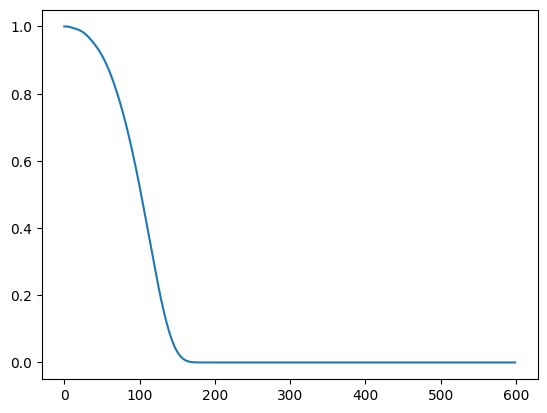

In [71]:
plot(dat)

In [72]:
dat = []
u0, v0, _ = states[0]

for ui, vi, _ in states:
    Aq = np.conj(u0)*ui + np.conj(v0)*vi   # mode overlaps
    logP = 2*np.sum(np.log(np.abs(Aq)))    # many-body overlap
    dat.append(logP)

dat = np.array(dat)   # this is log |⟨Ψ0|Ψ(t)⟩|^2


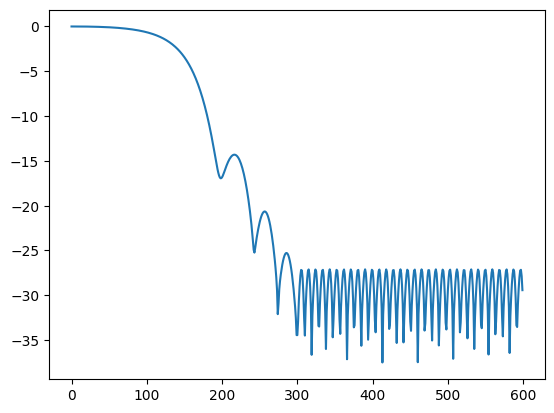

In [73]:
plot(dat)
show()


In [74]:
colors = ["blue","red","green"]

0.0


/home/kristian/Desktop/subsystem_loschmidt_echo/scripts/0_quench_then_hold/../../src/time_evolved_z_correlators.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = kz.D(-Nd,state)


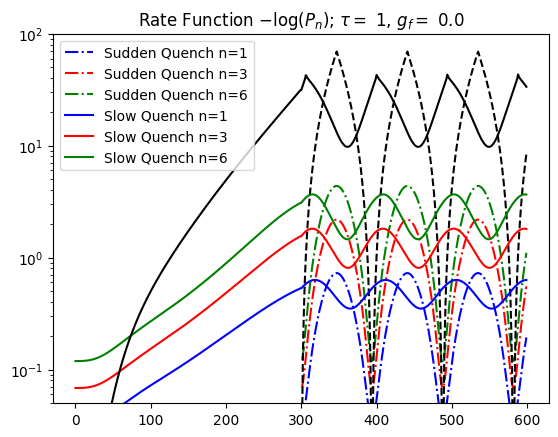

In [99]:
L = 100
tau = .000001

ts = (-tau,tau)
gf = 1- ( ts[1]/tau)
print(gf)
states,t = landau_states(tau,L,ts=ts)
ns = [1,3,6]
for c,n in zip(colors,ns):
    datx = array([(-log(zz.P_n(n,s))) for s in states])
    plot(np.arange(len(t))[len(t)//2+1:],(datx)[len(t)//2+1:],label=f"Sudden Quench n={n}",ls="-.",color=c)
plot(np.arange(len(t)),-log(GroundStateOverlap(states)),"--k")
legend()
L = 100
tau = 1
ts = (-tau,tau)

states,t = landau_states(tau,L,ts=ts)
for c,n in zip(colors,ns):
    datx = array([-log(zz.P_n(n,s)) for s in states])
    plot(np.arange(len(t)),(datx),label=f"Slow Quench n={n}",color=c)
plot(np.arange(len(t)),-log(GroundStateOverlap(states)),color="black")
#plt.vlines(len(t)/2,0,1,color="black")
yscale("log")
ylim(.05,100)
title(rf"Rate Function $-\log (P_n)$; $\tau = $ {tau}, $g_f = $ {gf}")
#xlim(200,400)
legend()